In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from typing import Dict, List, Union
from scipy.stats import norm

**HW 2/1**: <br>
Smart up our plotter to be able to customize the hard-coded layout setup inside the function. Add more custom feature that you would like to use.

Added features:

1. Customizable kwargs (I use this in the 4th assignment to create dashed lines)

In [96]:
# some type hints in the header of the function
def my_plotter(x: List[float], y: Union[List[float], List[List[float]]], plot_kwargs: List[Dict] = None, layout: Dict = {}, names: List[str] = None) -> None:
    """ inline for loop is called 'list comprehension' """
    y = [y] if all(isinstance(item, float) for item in y) else y
    
    plt.figure(figsize=(8, 4))
    lines = []
    show_legend = True if names is not None else False
    # show_legend = True if names else False  -> here is fine, but be cautious bc 0, empty str and empty list will be evaulated to False

    """ setup some basic key-word arguments for plot line """
    plot_kwargs_0 = {
        'linestyle': 'solid',
        'linewidth': 4
    }
    if names is not None:
        show_legend = True
        if len(names) != len(y):
            raise ValueError("Length of names is not matching with number of plotted y lists.")

    """ 'enumerate' add a counter to the loop """
    for i, y_item in enumerate(y):
        if plot_kwargs is not None and plot_kwargs[i] is not None:
            if show_legend:
                plot_kwargs[i]['label'] = names[i]
            _line = plt.plot(x, y_item, **plot_kwargs[i])
        else:
            if show_legend:
                plot_kwargs_0['label'] = names[i]
            _line = plt.plot(x, y_item, **plot_kwargs_0)
        lines.append(_line)

    if show_legend:
        plt.legend(fontsize=16)
    if 'title' in layout:
        plt.title(layout['title'], fontsize=20)
        rcParams['axes.titlepad'] = 30 # moving the title a little further away from the plot
    if 'x_label' in layout:
        plt.xlabel(layout['x_label'], fontsize=16)
        rcParams['axes.labelpad'] = 20 # moving the ax label a little further away from the plot

    """ enhance axes """
    ax = plt.gca() # gca: get current axes
    ax.axhline(linestyle='--', color='black', linewidth=1)
    plt.show()

**HW 2/2**: <br>
Upgrade the BSM call option pricer to be able to return the greeks as well, not just the price.

By derivating the BSM pricing formula of European call, we can get analytical solutions for these derivatives of the call option price:

<table>
    <tr>
        <th>Greek</th><th>Formula for call option</th>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Delta = c'_S
            \end{equation} 
        </td>
        <td>
            \begin{equation}
                N(d_1)
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \mathcal{V} = c'_\sigma
            \end{equation}
        </td>
        <td>
            \begin{equation}
                S_t \cdot N'(d_1) \cdot\sqrt{T-t}
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Theta = c'_\tau
            \end{equation}
        </td>
        <td>
            \begin{equation}
                -S_t \cdot N'(d_1)\cdot \frac{\sigma}{2\sqrt{T-t}} - r\cdot K\cdot e^{-r(T-t)}\cdot N(d_2)
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \rho = c'_r
            \end{equation}
        </td>
        <td>
            \begin{equation}
                K\cdot (T-t)\cdot e^{-r(T-t)}\cdot N(d_2)
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Gamma = \Delta'_S = c''_{SS}
            \end{equation}
        </td>
        <td>
            \begin{equation}
                N'(d_1) \cdot \frac{1}{S_t\cdot\sigma\sqrt{T-t}}
            \end{equation} 
        </td>
    </tr>
</table>

where $N$ is the cummulative distribution function and $N'$ is the probability density function of the standard normal distribution, and
\begin{equation}
d_1 = \frac{log(S_0 / K) + (r + \sigma^2 / 2)T}{\sigma\sqrt{T}}  \quad \text{ and } \quad d_2 = d_1 - \sigma\sqrt{T}.
\end{equation}

In [97]:
"""The pricing function of European call option"""
def black_scholes_eur_call(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray]) -> List[np.ndarray]:
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)
    
    # calculate option price
    c_vec = N_d1_vec * S0 - K_vec * np.exp((-1.0)*r*T) * N_d2_vec
    
    # calculate derivatives
    delta_vec = N_d1_vec
    vega_vec = S0 * norm.pdf(d1_vec) * T**0.5
    theta_vec = (-1.0) * S0 * norm.pdf(d1_vec) * sigma / (2 * T**0.5) - r * K * np.exp((-1.0)*r*T) * N_d2_vec
    rho_vec = K * T * np.exp((-1.0)*r*T) * N_d2_vec
    gamma_vec = norm.pdf(d1_vec) / (S0 * sigma * T**0.5)
    
    return [c_vec, delta_vec, vega_vec, theta_vec, rho_vec, gamma_vec]

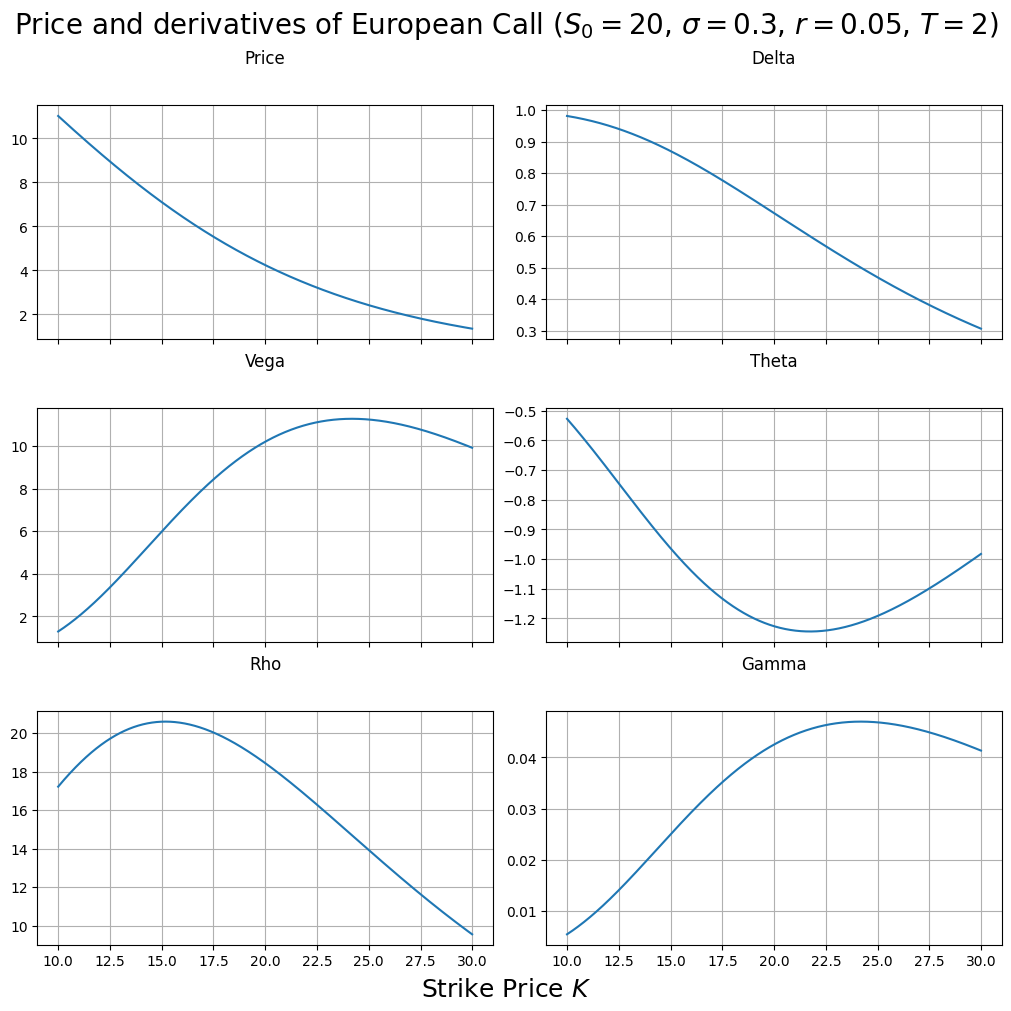

In [98]:
## Plot price and derivatives for european call option with set parameters
K_vec = np.arange(10, 30, 0.01)
report = black_scholes_eur_call(0.05, 2, 20, 0.3, K_vec)

labels = ['Price', 'Delta', 'Vega', 'Theta', 'Rho', 'Gamma']

fig, axs = plt.subplots(3, 2, sharex='all', figsize=(10, 10), layout='constrained')

fig.suptitle('Price and derivatives of European Call ($S_0 = 20$, $\\sigma = 0.3$, $r = 0.05$, $T = 2$)', fontsize=20)
fig.supxlabel('Strike Price $K$', fontsize=18)

for y, title, axis in zip(report, labels, axs.flat):
    axis.plot(K_vec, y)
    axis.set_title(title)
    axis.grid(True)
    
plt.show()

**HW 2/3**: <br>
Implement the BSM pricer for European put option.

Using the same notation as before, the BSM formula for European put option is

\begin{equation}
c = K\cdot e^{-rT} \cdot N(-d_2) - S_0 \cdot N(-d_1)
\end{equation}

The corresponding derivatives of the put option price are as follows:

<table>
    <tr>
        <th>Greek</th><th>Formula for put option</th>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Delta = c'_S
            \end{equation} 
        </td>
        <td>
            \begin{equation}
                N(d_1) - 1
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \mathcal{V} = c'_\sigma
            \end{equation}
        </td>
        <td>
            \begin{equation}
                S_t \cdot N'(d_1) \cdot\sqrt{T-t}
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Theta = c'_\tau
            \end{equation}
        </td>
        <td>
            \begin{equation}
                -S_t \cdot N'(d_1)\cdot \frac{\sigma}{2\sqrt{T-t}} + r\cdot K\cdot e^{-r(T-t)}\cdot N(-d_2)
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \rho = c'_r
            \end{equation}
        </td>
        <td>
            \begin{equation}
                -K\cdot (T-t)\cdot e^{-r(T-t)}\cdot N(-d_2)
            \end{equation} 
        </td>
    </tr>
    <tr>
        <td>
            \begin{equation}
                \Gamma = \Delta'_S = c''_{SS}
            \end{equation}
        </td>
        <td>
            \begin{equation}
                N'(d_1) \cdot \frac{1}{S_t\cdot\sigma\sqrt{T-t}}
            \end{equation} 
        </td>
    </tr>
</table>

In [99]:
"""The pricing function of European put option"""
def black_scholes_eur_put(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray]) -> np.ndarray:
    """
    Black-Scholes pricer of European call option on non-dividend-paying stock

    param r: risk-free interest rate (which is constant)
    param T: time to maturity (in years)
    param S0: initial spot price of the underlying stock
    param sigma: volatility of the underlying stock
    param K: strike price (or prices)
    """
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)

    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5

    N_d1_vec = norm.cdf(d1_vec)
    N_minus_d1_vec = norm.cdf((-1.0)*d1_vec)
    N_d2_vec = norm.cdf(d2_vec)
    N_minus_d2_vec = norm.cdf((-1.0)*d2_vec)

    # calculate price
    c_vec = K_vec * np.exp((-1.0)*r*T) * N_minus_d2_vec -  N_minus_d1_vec * S0

    # calculate derivatives
    delta_vec = N_d1_vec - 1
    vega_vec = S0 * norm.pdf(d1_vec) * T**0.5
    theta_vec = (-1.0) * S0 * norm.pdf(d1_vec) * sigma / (2 * T**0.5) + r * K * np.exp((-1.0)*r*T) * N_minus_d2_vec
    rho_vec = (-1.0) * K * T * np.exp((-1.0)*r*T) * N_minus_d2_vec
    gamma_vec = norm.pdf(d1_vec) / (S0 * sigma * T**0.5)
    
    return [c_vec, delta_vec, vega_vec, theta_vec, rho_vec, gamma_vec]

**HW 2/4**: <br>
With the call and put pricer, check if Put-Call parity holds in practice.

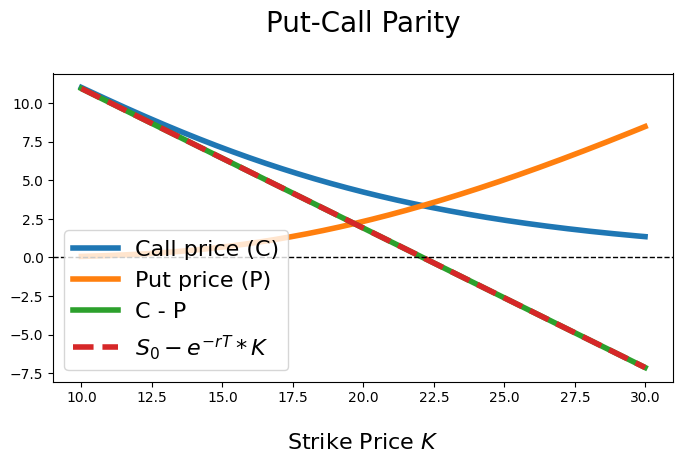

In [100]:
r = 0.05
T = 2
S0 = 20
sigma = 0.3
K_vec = np.arange(10, 30, 0.01)

call_price = black_scholes_eur_call(r, T, S0, sigma, K_vec)[0]
put_price = black_scholes_eur_put(r, T, S0, sigma, K_vec)[0]

discounted_K = np.exp((-1.0)*r*T) * K_vec

layout = {'title': 'Put-Call Parity', 'x_label': 'Strike Price $K$'}
plot_kwargs = [None,
               None,
               None,
               {'linestyle': 'dashed',
                'linewidth': 4}]

my_plotter(K_vec, [call_price, put_price, call_price - put_price, S0 - discounted_K], plot_kwargs=plot_kwargs, layout=layout,
          names = ['Call price (C)', 'Put price (P)', 'C - P', '$S_0 - e^{-rT} * K$'])